In [1]:
import pandas as pd
import os
from pathlib import Path
from icecream import ic
import plotly.subplots as sp
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [2]:
ROOT_DIR = Path.cwd().parent.resolve()
DATA_DIR = ROOT_DIR / 'data' / 'raw' / 'data'

t1dm_path = DATA_DIR / 'Shanghai_T1DM_Summary.xlsx'
t2dm_path = DATA_DIR / 'Shanghai_T2DM_Summary.xlsx'

In [3]:
t1dm_summary = pd.read_excel(t1dm_path)
t1dm_summary.head(10)

,Patient Number,"Gender (Female=1, Male=2)",Age (years),Height (m),Weight (kg),BMI (kg/m2),Smoking History (pack year),Alcohol Drinking History (drinker/non-drinker),Type of Diabetes,Duration of Diabetes (years),...,Glycated Albumin (%),Total Cholesterol (mmol/L),Triglyceride (mmol/L),High-Density Lipoprotein Cholesterol (mmol/L),Low-Density Lipoprotein Cholesterol (mmol/L),Creatinine (umol/L),Estimated Glomerular Filtration Rate (ml/min/1.73m2),Uric Acid (mmol/L),Blood Urea Nitrogen (mmol/L),Hypoglycemia (yes/no)
0,1001_0_20210730,1,66,1.50,60.0,26.666667,0.0,non-drinker,T1DM,10.000000,...,40.7,3.59,1.02,0.86,2.01,37.3,160,188.86,6.47,no
1,1002_0_20210504,2,68,1.70,63.0,21.799308,50.0,drinker,T1DM,26.000000,...,19.6,4.78,2.20,0.93,3.28,66.8,109,342.57,6.05,yes
2,1002_1_20210521,2,68,1.70,67.0,23.183391,50.0,drinker,T1DM,26.000000,...,19.6,4.78,2.20,0.93,3.28,69.4,104,322.18,3.06,yes
3,1002_2_20210909,2,68,1.70,65.0,22.491349,50.0,drinker,T1DM,26.000000,...,25.1,3.49,1.82,0.84,1.83,63.7,115,342.34,6.21,yes
4,1003_0_20210831,2,37,1.90,60.0,16.620499,0.0,non-drinker,T1DM,0.083333,...,46.6,5.61,1.14,1.08,3.95,49.6,174,93.39,1.85,yes
5,1004_0_20210425,1,67,1.55,47.0,19.562955,0.0,non-drinker,T1DM,12.000000,...,37.6,4.57,0.91,1.27,2.76,45.2,127,240.61,3.98,yes
6,1005_0_20210522,2,58,1.70,50.0,17.301038,22.5,non-drinker,T1DM,16.000000,...,25.7,4.05,0.46,1.57,2.12,75.4,98,205.48,3.96,yes
7,1006_0_20210114,2,57,1.61,53.2,20.523900,0.0,non-drinker,T1DM,7.000000,...,29.2,4.44,0.68,1.97,2.57,74,97,247,6.4,yes
8,1006_1_20210209,2,57,1.61,52.3,20.180000,0.0,non-drinker,T1DM,7.000000,...,27,5.12,0.64,1.88,2.93,82,91,257,6.4,yes
9,1006_2_20210303,2,57,1.60,51.6,20.160000,0.0,non-drinker,T1DM,7.000000,...,26.6,4.27,0.54,1.72,2.63,73,97,201,7.3,yes


In [4]:
t1dm_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 33 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Patient Number                                          16 non-null     str    
 1   Gender (Female=1, Male=2)                               16 non-null     int64  
 2   Age (years)                                             16 non-null     int64  
 3   Height (m)                                              16 non-null     float64
 4   Weight (kg)                                             16 non-null     float64
 5   BMI (kg/m2)                                             16 non-null     float64
 6   Smoking History (pack year)                             16 non-null     float64
 7   Alcohol Drinking History (drinker/non-drinker)          16 non-null     str    
 8   Type of Diabetes                                     

- patient number - all unique?
- gender into 0/1 encoding
- check numerical cols ranges
- bmi stats in categorical
- alcohol drinker to binary
- type of diabetes to int
- inspect str columns
- calculate hom index


In [5]:
t1dm_summary.describe()

,"Gender (Female=1, Male=2)",Age (years),Height (m),Weight (kg),BMI (kg/m2),Smoking History (pack year),Duration of Diabetes (years),Fasting Plasma Glucose (mg/dl),Total Cholesterol (mmol/L),Triglyceride (mmol/L),High-Density Lipoprotein Cholesterol (mmol/L),Low-Density Lipoprotein Cholesterol (mmol/L)
count,16.000000,16.000000,16.000000,16.00000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,1.562500,59.000000,1.653750,57.78750,21.189323,11.200000,11.570106,193.230000,4.642500,1.127500,1.396875,2.781875
std,0.512348,10.152175,0.094225,9.47283,3.547238,20.073365,9.205545,86.486582,0.595029,0.592953,0.509964,0.707373
min,1.000000,37.000000,1.500000,35.00000,13.671875,0.000000,0.038356,80.280000,3.490000,0.460000,0.770000,1.740000
25%,1.000000,56.000000,1.607500,52.12500,20.010739,0.000000,5.250000,117.000000,4.397500,0.670000,0.922500,2.375000
50%,2.000000,58.500000,1.625000,60.00000,20.945606,0.000000,8.500000,181.800000,4.665000,0.965000,1.375000,2.705000
75%,2.000000,67.250000,1.700000,64.25000,22.875738,10.650000,17.750000,252.225000,5.097500,1.620000,1.850000,3.280000
max,2.000000,73.000000,1.900000,74.00000,27.513385,50.000000,26.000000,352.800000,5.610000,2.200000,2.330000,4.250000


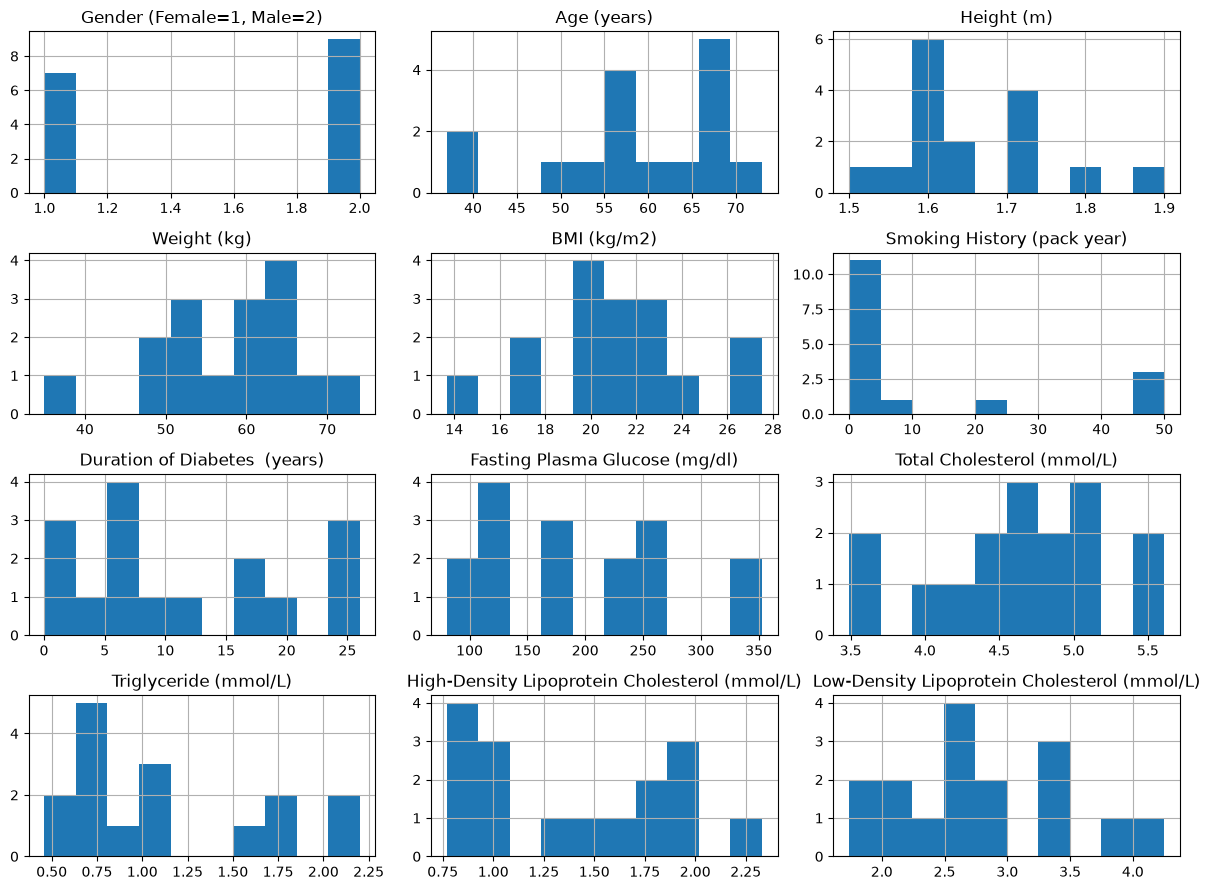

In [6]:
t1dm_summary.hist(figsize=(12,9))
plt.tight_layout()
plt.show()

In [7]:
t2dm_summary = pd.read_excel(t2dm_path)
t2dm_summary.head(10)

,Patient Number,"Gender (Female=1, Male=2)",Age (years),Height (m),Weight (kg),BMI (kg/m2),Smoking History (pack year),Alcohol Drinking History (drinker/non-drinker),Type of Diabetes,Duration of diabetes (years),...,Glycated Albumin (%),Total Cholesterol (mmol/L),Triglyceride (mmol/L),High-Density Lipoprotein Cholesterol (mmol/L),Low-Density Lipoprotein Cholesterol (mmol/L),Creatinine (umol/L),Estimated Glomerular Filtration Rate (ml/min/1.73m2),Uric Acid (mmol/L),Blood Urea Nitrogen (mmol/L),Hypoglycemia (yes/no)
0,2000_0_20201230,2,57,1.69,67.4,23.600000,0.00,non-drinker,T2DM,25.000000,...,14.9,4.07,0.61,2.28,1.86,105,68,245,4.9,yes
1,2001_0_20201102,1,69,1.45,55.8,26.540000,0.00,non-drinker,T2DM,14.000000,...,15.3,4.36,0.89,1.36,2.89,41,101,337,5.6,yes
2,2001_1_20201117,1,69,1.45,53.2,25.300000,0.00,non-drinker,T2DM,14.000000,...,17,4.28,0.93,1.13,2.94,39,103,262,3.7,no
3,2002_0_20210513,2,57,1.70,70.0,24.221453,30.00,drinker,T2DM,10.000000,...,29.8,5.31,1.32,1.33,3.68,71.5,105,475.6,4.74,no
4,2003_0_20210615,1,58,1.64,62.5,23.237656,0.00,non-drinker,T2DM,22.000000,...,19.5,4.73,1.73,0.91,2.95,36.9,166,490.05,5.54,no
5,2004_0_20211028,1,78,1.55,60.0,24.973985,0.00,non-drinker,T2DM,20.000000,...,38.1,2.63,1.53,0.71,1.19,49,113,230.09,3.96,no
6,2005_0_20211201,1,67,1.60,57.5,22.460938,0.00,non-drinker,T2DM,0.005479,...,33.3,7.35,7.65,1.11,4.04,47.8,120,320.27,5.9,no
7,2006_0_20211112,1,35,1.69,55.0,19.257029,0.00,non-drinker,T2DM,8.000000,...,32.1,6.19,2.45,1.03,4.55,27.7,257,172.62,3.77,no
8,2007_0_20220108,2,68,1.65,51.5,18.916437,11.25,drinker,T2DM,0.038356,...,/,6.29,1.48,2.56,3.28,87.2,80,202.88,9.51,no
9,2008_0_20220118,2,61,1.80,80.0,24.690000,7.50,drinker,T2DM,12.000000,...,21.5,2.91,0.79,0.89,1.82,70,106,282.41,6.16,yes


In [8]:
t2dm_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 33 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Patient Number                                          109 non-null    str    
 1   Gender (Female=1, Male=2)                               109 non-null    int64  
 2   Age (years)                                             109 non-null    int64  
 3   Height (m)                                              109 non-null    float64
 4   Weight (kg)                                             109 non-null    float64
 5   BMI (kg/m2)                                             109 non-null    float64
 6   Smoking History (pack year)                             109 non-null    float64
 7   Alcohol Drinking History (drinker/non-drinker)          109 non-null    str    
 8   Type of Diabetes                                   

In [9]:
t2dm_summary.describe()

,"Gender (Female=1, Male=2)",Age (years),Height (m),Weight (kg),BMI (kg/m2),Smoking History (pack year),Duration of diabetes (years)
count,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,1.541284,60.302752,1.655321,66.290826,24.093780,3.555046,8.691180
std,0.500594,14.006285,0.095198,12.007240,3.312370,11.660532,8.256633
min,1.000000,22.000000,1.415000,40.000000,17.087445,0.000000,0.005479
25%,1.000000,51.000000,1.590000,56.000000,22.222222,0.000000,1.000000
50%,2.000000,63.000000,1.660000,66.000000,23.597004,0.000000,7.000000
75%,2.000000,68.000000,1.720000,73.000000,25.471663,0.000000,14.000000
max,2.000000,97.000000,1.880000,100.000000,36.730946,80.000000,40.000000


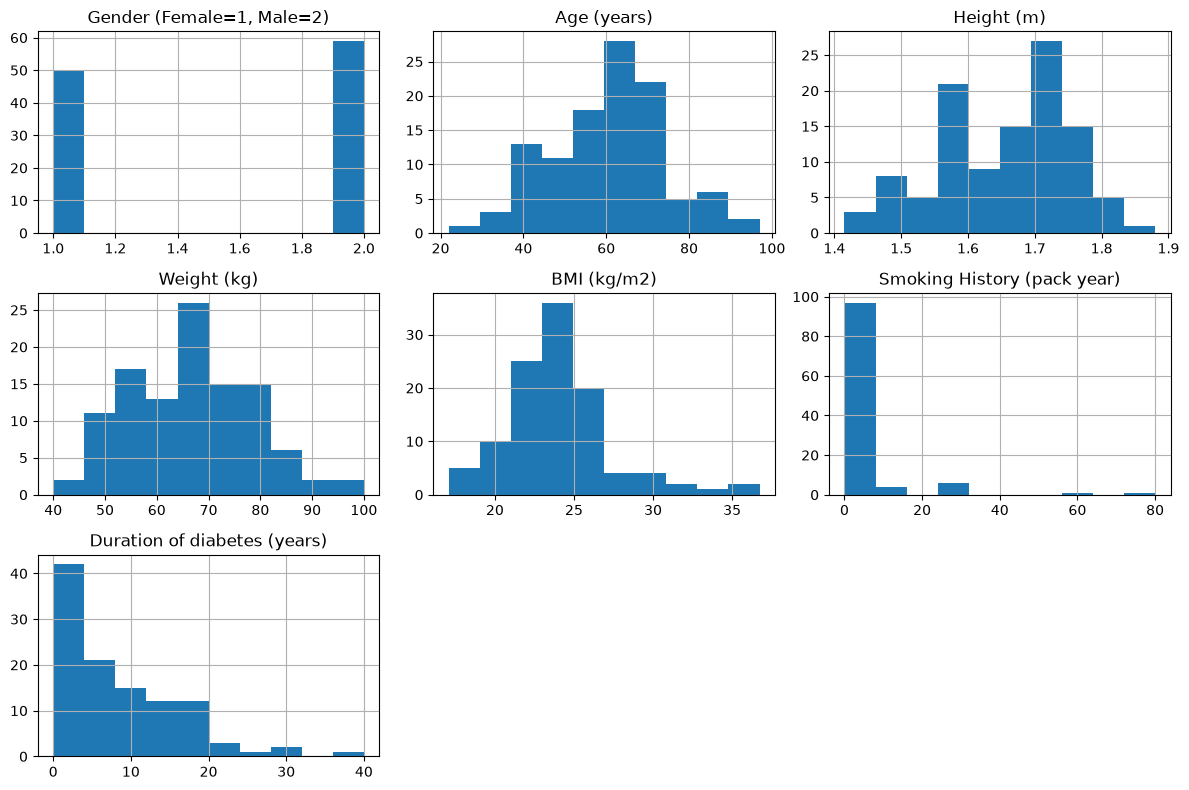

In [10]:
t2dm_summary.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [11]:
diff_cols = set(t1dm_summary.columns) - set(t2dm_summary.columns)
ic(diff_cols)
diff_cols = set(t2dm_summary.columns) - set(t1dm_summary.columns)
ic(diff_cols)

ic| diff_cols: {'Duration of Diabetes  (years)', '2-hour Postprandial Insulin (pmol/L)'}
ic| diff_cols: {'Duration of diabetes (years)', '2-hour Postprandial insulin (pmol/L)'}


{'2-hour Postprandial insulin (pmol/L)', 'Duration of diabetes (years)'}

the columns are the same in both datasets. have to apply .lower()

In [12]:
t1_ts_path = DATA_DIR / 'Shanghai_T1DM'
patient = t1dm_summary['Patient Number'][0]
t1_ts_df = pd.read_excel(t1_ts_path / (patient + '.xlsx'))

In [13]:
t1_ts_df.head()

,Date,CGM (mg / dl),CBG (mg / dl),Blood Ketone (mmol / L),Dietary intake,饮食,Insulin dose - s.c.,Non-insulin hypoglycemic agents,"CSII - bolus insulin (Novolin R, IU)","CSII - basal insulin (Novolin R, IU / H)",Insulin dose - i.v.
0,2021-07-30 16:43:00,113.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3,NaN
1,2021-07-30 16:58:00,124.2,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
2,2021-07-30 17:13:00,129.6,NaN,NaN,data not available,未记录,NaN,NaN,NaN,NaN,NaN
3,2021-07-30 17:28:00,142.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-07-30 17:43:00,156.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**CGM** stands for **Continuous Glucose Monitor**. It measures blood glucose levels continuously, with readings typically every 5-15 minutes.

**mg/dL** (milligrams per deciliter) is the standard unit for blood glucose measurement.

- CGM readings show real-time glucose trends
- Normal fasting glucose: 70-100 mg/dL
- Hyperglycemia (high): > 200 mg/dL
- Hypoglycemia (low): < 70 mg/dL


**CBG** stands for **Capillary Blood Glucose** (or sometimes just called fingerstick glucose).

## Key differences from CGM:

| CBG | CGM |
|-----|-----|
| Point-in-time measurement | Continuous readings |
| From finger prick blood sample | Sensor under skin |
| Less frequent (few times daily) | Every 5-15 minutes |
| More accurate | Estimates glucose trend |
| mg/dL units | mg/dL units |

- CBG = manual blood glucose checks (gold standard for accuracy)
- CGM = continuous monitoring (shows trends and patterns)

## Common use in diabetes data:
- CBG readings are often used to **calibrate/validate** CGM sensors
- Both together give a complete picture: accuracy (CBG) + trends (CGM)
- I might use CBG to check if your CGM predictions are accurate

I can analyze how well CGM tracks actual blood glucose.


In [14]:
t1_ts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 658 entries, 0 to 657
Data columns (total 11 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Date                                      658 non-null    datetime64[us]
 1   CGM (mg / dl)                             658 non-null    float64       
 2   CBG (mg / dl)                             53 non-null     float64       
 3   Blood Ketone (mmol / L)                   0 non-null      float64       
 4   Dietary intake                            22 non-null     str           
 5   饮食                                        22 non-null     str           
 6   Insulin dose - s.c.                       0 non-null      float64       
 7   Non-insulin hypoglycemic agents           6 non-null      str           
 8   CSII - bolus insulin (Novolin R, IU)      29 non-null     float64       
 9   CSII - basal insulin (Novolin R, IU / H)  4

In [15]:
t1_ts_df.shape

(658, 11)

In [16]:
t1_ts_df.describe()

,Date,CGM (mg / dl),CBG (mg / dl),Blood Ketone (mmol / L),Insulin dose - s.c.,"CSII - bolus insulin (Novolin R, IU)","CSII - basal insulin (Novolin R, IU / H)",Insulin dose - i.v.
count,658,658.000000,53.000000,0.0,0.0,29.000000,44.000000,0.0
mean,2021-08-03 02:50:30,196.829179,253.324528,NaN,NaN,5.275862,0.454545,NaN
min,2021-07-30 16:43:00,48.600000,104.400000,NaN,NaN,2.000000,0.200000,NaN
25%,2021-08-01 09:46:45,163.800000,201.600000,NaN,NaN,4.000000,0.300000,NaN
50%,2021-08-03 02:50:30,195.300000,266.400000,NaN,NaN,5.000000,0.500000,NaN
75%,2021-08-04 19:54:15,230.400000,297.000000,NaN,NaN,6.000000,0.500000,NaN
max,2021-08-06 12:58:00,307.800000,379.800000,NaN,NaN,10.000000,0.600000,NaN
std,NaN,50.141982,63.309936,NaN,NaN,2.169538,0.128415,NaN


- do we have 1 week for each patient?
- how frequent are the measurements?
- do they have the same frequency for all patients?

In [17]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=t1_ts_df['Date'], y=t1_ts_df['CGM (mg / dl)'], mode='lines', name='CGM'))
fig.add_trace(go.Scatter(x=t1_ts_df['Date'], y=t1_ts_df['CBG (mg / dl)'], mode='markers', name='CBG'))

# Low glucose (hypoglycemia)
fig.add_hrect(y0=0, y1=70, fillcolor="red", opacity=0.2, layer="below", name="Low")

# Normal glucose
fig.add_hrect(y0=70, y1=200, fillcolor="green", opacity=0.2, layer="below", name="Normal")

# High glucose (hyperglycemia)
fig.add_hrect(y0=200, y1=400, fillcolor="orange", opacity=0.2, layer="below", name="High")


fig.update_layout(title=f'Glucose Measurements Over Time for patient {patient}', xaxis_title='DateTime', yaxis_title='Glucose Levels (mg / dl)')
fig.show()

- For this patient it seems like CGM underestimates glucose levels. is it the same for other patients?
- what is a better (CGM or CBG or TIR) predictive value for HbA1c?
- ML model: predict HbA1c from TIR/TOR pair in 1 week period.

In [18]:
t2_ts_path = DATA_DIR / 'Shanghai_T2DM'
patient = t2dm_summary['Patient Number'][0]
t2_ts_df = pd.read_excel(t2_ts_path / (patient + '.xlsx'))

In [19]:
t2_ts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 11 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Date                                      1339 non-null   datetime64[us]
 1   CGM (mg / dl)                             1339 non-null   float64       
 2   CBG (mg / dl)                             32 non-null     float64       
 3   Blood Ketone (mmol / L)                   0 non-null      float64       
 4   Dietary intake                            41 non-null     str           
 5   饮食                                        41 non-null     str           
 6   Insulin dose - s.c.                       28 non-null     str           
 7   Non-insulin hypoglycemic agents           0 non-null      float64       
 8   CSII - bolus insulin (Novolin R, IU)      0 non-null      float64       
 9   CSII - basal insulin (Novolin R, IU / H) 

In [20]:
t2_ts_df.describe()

,Date,CGM (mg / dl),CBG (mg / dl),Blood Ketone (mmol / L),Non-insulin hypoglycemic agents,"CSII - bolus insulin (Novolin R, IU)","CSII - basal insulin (Novolin R, IU / H)",Insulin dose - i.v.
count,1339,1339.000000,32.000000,0.0,0.0,0.0,0.0,0.0
mean,2021-01-06 13:09:00,118.959970,109.237500,NaN,NaN,NaN,NaN,NaN
min,2020-12-30 13:54:00,39.600000,46.800000,NaN,NaN,NaN,NaN,NaN
25%,2021-01-03 01:31:30,93.600000,88.200000,NaN,NaN,NaN,NaN,NaN
50%,2021-01-06 13:09:00,113.400000,101.700000,NaN,NaN,NaN,NaN,NaN
75%,2021-01-10 00:46:30,140.400000,131.400000,NaN,NaN,NaN,NaN,NaN
max,2021-01-13 12:24:00,252.000000,232.200000,NaN,NaN,NaN,NaN,NaN
std,NaN,35.918195,36.637243,NaN,NaN,NaN,NaN,NaN


- this patient has 2 weeks of data available. TODO: check durations of all patients' records

In [21]:
t1_patients = t1dm_summary['Patient Number'].to_list()
t2_patients = t2dm_summary['Patient Number'].to_list()

t1_all_ts = {}
t2_all_ts = {}

for patient in t1_patients:
    try:
        df = pd.read_excel(DATA_DIR / 'Shanghai_T1DM' / (patient + '.xlsx'))
    except FileNotFoundError:
        df = pd.read_excel(DATA_DIR / 'Shanghai_T1DM' / (patient + '.xls'))
    t1_all_ts[patient] = df

for patient in t2_patients:
    try:
        df = pd.read_excel(DATA_DIR / 'Shanghai_T2DM' / (patient + '.xlsx'))
    except FileNotFoundError:
        df = pd.read_excel(DATA_DIR / 'Shanghai_T2DM' / (patient + '.xls'))
    t2_all_ts[patient] = df

In [22]:
t2_ts_df.shape

(1339, 11)

In [23]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=t2_ts_df['Date'], y=t2_ts_df['CGM (mg / dl)'], mode='lines', name='CGM'))
fig.add_trace(go.Scatter(x=t2_ts_df['Date'], y=t2_ts_df['CBG (mg / dl)'], mode='markers', name='CBG'))

# Low glucose (hypoglycemia)
fig.add_hrect(y0=0, y1=70, fillcolor="red", opacity=0.2, layer="below", name="Low")

# Normal glucose
fig.add_hrect(y0=70, y1=200, fillcolor="green", opacity=0.2, layer="below", name="Normal")

# High glucose (hyperglycemia)
fig.add_hrect(y0=200, y1=400, fillcolor="orange", opacity=0.2, layer="below", name="High")


fig.update_layout(title=f'Glucose Measurements Over Time for patient {patient}', xaxis_title='DateTime', yaxis_title='Glucose Levels (mg / dl)')
fig.show()

- Here CGM and CBG agree